<a href="https://colab.research.google.com/github/mw12anek/Computer-Science-class/blob/main/Datascienceintro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Monthly Data Head ---
            Monthly_Change
2010-01-31       -1.150024
2010-02-28       -0.793529
2010-03-31        0.190165
2010-04-30        1.200649
2010-05-31        1.220392


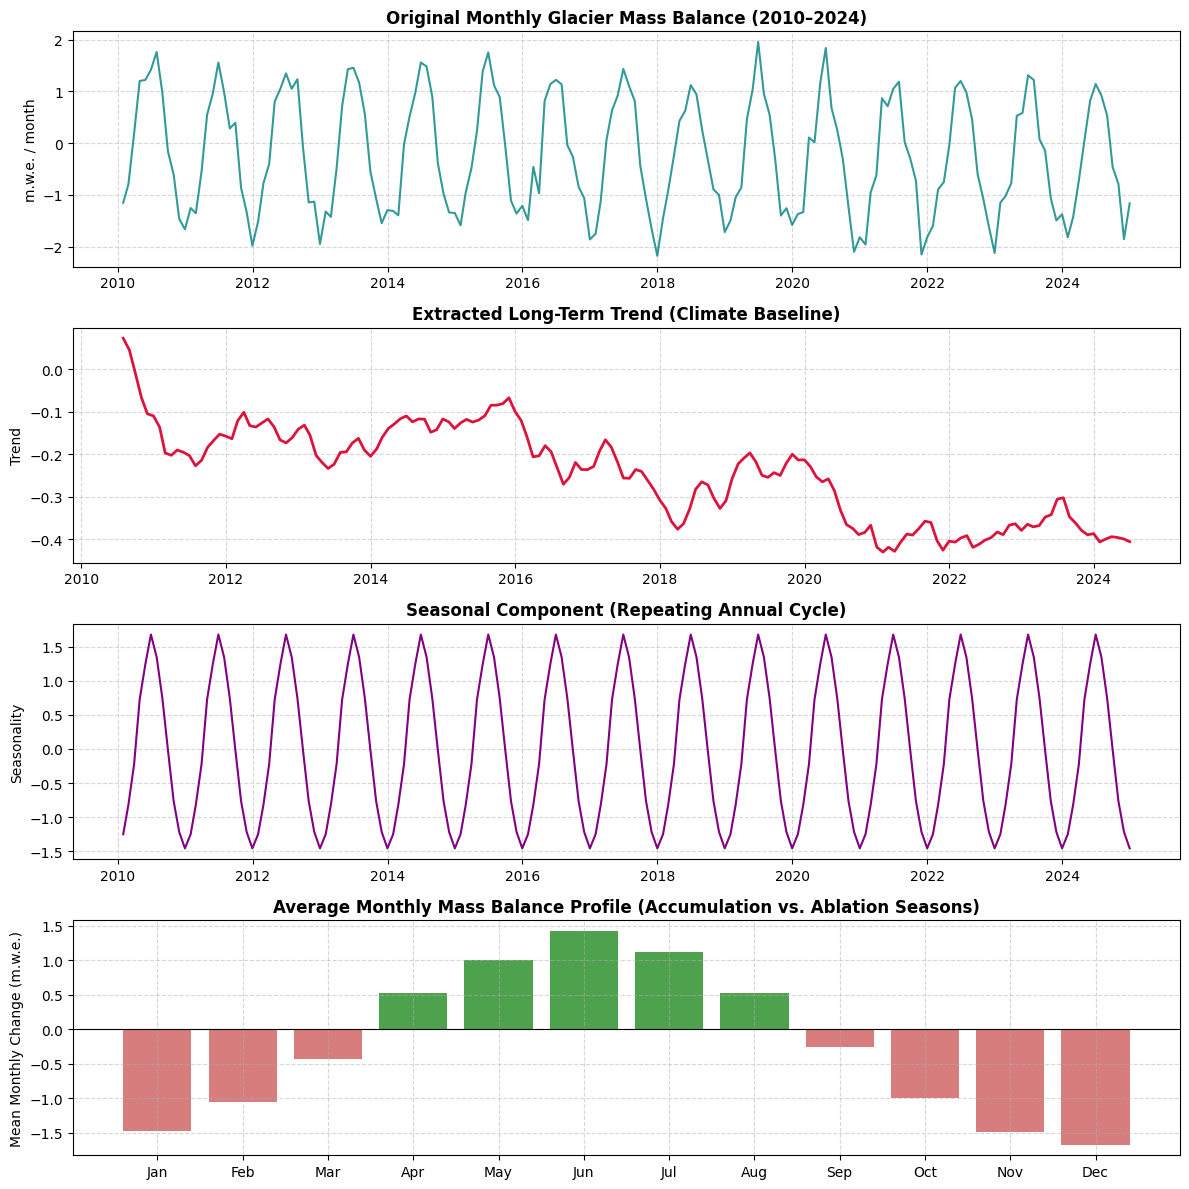

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ==========================================
# 1. GENERATE MONTHLY GLACIER DATA (WITH SEASONALITY)
# ==========================================
np.random.seed(42)

# Create a monthly date range from January 2010 to December 2024 (180 months)
dates = pd.date_range(start='2010-01-01', end='2024-12-31', freq='ME')
n = len(dates)

# Components of the time series:
# 1. Trend: Gradual long-term downward trend (climate change)
trend = -0.02 * np.arange(n) - 0.0005 * (np.arange(n) ** 1.5)

# 2. Seasonality: Sinusoidal pattern (Positive in winter months, deeply negative in summer months)
# Month 1 = Jan (Winter -> Accumulation), Month 7 = July (Summer -> Ablation/Melt)
month_of_year = dates.month
seasonality = 1.5 * np.sin(2 * np.pi * (month_of_year - 3) / 12)  # Peaks in spring, drops in summer

# 3. Noise: Random weather anomalies
noise = np.random.normal(0, 0.3, n)

# Combine components into monthly mass balance change (meters of water equivalent per month)
monthly_mass_change = trend/10 + seasonality + noise

df = pd.DataFrame({'Monthly_Change': monthly_mass_change}, index=dates)

print("--- Monthly Data Head ---")
print(df.head())

# ==========================================
# 2. TIME SERIES DECOMPOSITION
# ==========================================
# Decompose the time series into Trend, Seasonal, and Residual components (Additive Model, period=12 months)
decomposition = seasonal_decompose(df['Monthly_Change'], model='additive', period=12)

df['Trend'] = decomposition.trend
df['Seasonal'] = decomposition.seasonal
df['Residual'] = decomposition.resid

# ==========================================
# 3. GROUP-BY SEASONAL ANALYSIS
# ==========================================
# Calculate the average monthly melt/accumulation profile across all years
df['Month_Name'] = df.index.strftime('%b')
monthly_avg = df.groupby(df.index.month)['Monthly_Change'].mean()
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# ==========================================
# 4. VISUALIZATION
# ==========================================
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=False)

# Plot 1: Original Monthly Data
axes[0].plot(df.index, df['Monthly_Change'], color='teal', alpha=0.8)
axes[0].set_title('Original Monthly Glacier Mass Balance (2010–2024)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('m.w.e. / month')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Trend Component
axes[1].plot(df.index, df['Trend'], color='crimson', linewidth=2)
axes[1].set_title('Extracted Long-Term Trend (Climate Baseline)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Seasonal Component (The annual cycle)
axes[2].plot(df.index, df['Seasonal'], color='purple', linewidth=1.5)
axes[2].set_title('Seasonal Component (Repeating Annual Cycle)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonality')
axes[2].grid(True, linestyle='--', alpha=0.5)

# Plot 4: Average Monthly Profile (Bar chart)
axes[3].bar(months_order, monthly_avg, color=['forestgreen' if x > 0 else 'indianred' for x in monthly_avg], alpha=0.8)
axes[3].set_title('Average Monthly Mass Balance Profile (Accumulation vs. Ablation Seasons)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Mean Monthly Change (m.w.e.)')
axes[3].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()